In [16]:
import numpy as np
import matplotlib.pyplot as plt

data=np.genfromtxt('ex2data1.txt',delimiter=',')

X=data[:,0:2]
y=data[:,-1]

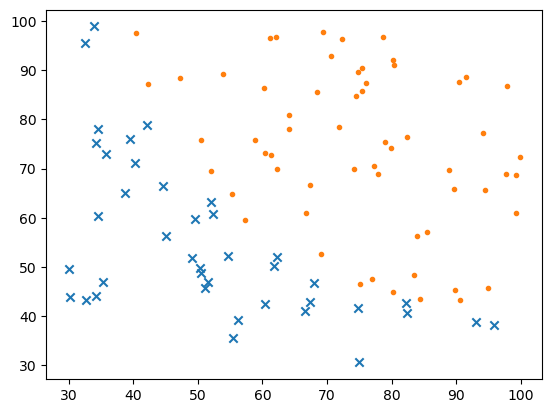

In [24]:
F=y==0
F_X=X[F]
T_X=X[~F]

fig,ax=plt.subplots()
ax.scatter(F_X[:,0],F_X[:,1],marker='x')
ax.scatter(T_X[:,0],T_X[:,1],marker='.')

i=np.linspace(0,100,101)
xx,yy=np.meshgrid(i,i)


In [121]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def err(X, y, w, b):
    
    m, n = X.shape
    total_cost=0
    for i in range(m):
        z=X[i]@w+b
        y_hat=sigmoid(z)
        err=(-y[i]*np.log(y_hat)-(1-y[i])*np.log(1-y_hat))
        total_cost+=err

    return total_cost/m

def df(X,y,w,b):
    M=X.shape[0]
    N=X.shape[1]
    dw=np.zeros(N)
    db=0
   
    for i in range(M):
        z=X[i]@w+b
        y_hat=sigmoid(z)
        err=y_hat-y[i]
        for j in range(N):
            dw[j]+=X[i,j]*err
        db+=err

    return dw/M,db/M


def fit(X,y,count,alpha):
    N=X.shape[1]
    w=np.zeros(N)
    b=0
    w=np.array(0.01 * (np.random.rand(2) - 0.5))
    b=-8
    result=[]
    for _ in range(count):
        dw,db=df(X,y,w,b)
        w=w-alpha*dw
        b=b-alpha*db
        e=err(X,y,w,b)
        print(f"迭代 {_+1:03d}次  | Error: {e:10.4f}") 
        
        result.append((w,b,e))
    return w,b,result
    

array([0.06742816, 0.06567059])

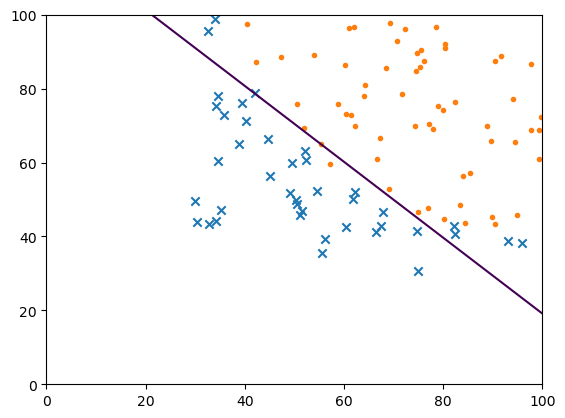

In [113]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std
w,b,best=fit(X,y,1000, 0.00001)
w1,w2=w
F=y==0
F_X=X[F]
T_X=X[~F]
fig,ax=plt.subplots()
ax.scatter(F_X[:,0],F_X[:,1],marker='x')
ax.scatter(T_X[:,0],T_X[:,1],marker='.')
i=np.linspace(0,100,101)
xx,yy=np.meshgrid(i,i)
zz=w1*xx+w2*yy+b
ax.contour(xx,yy,zz,levels=[0])

w

迭代 001次  | Error:     4.7914
迭代 002次  | Error:     4.7839
迭代 003次  | Error:     4.7764
迭代 004次  | Error:     4.7689
迭代 005次  | Error:     4.7613
迭代 006次  | Error:     4.7538
迭代 007次  | Error:     4.7463
迭代 008次  | Error:     4.7388
迭代 009次  | Error:     4.7312
迭代 010次  | Error:     4.7237
迭代 011次  | Error:     4.7162
迭代 012次  | Error:     4.7087
迭代 013次  | Error:     4.7011
迭代 014次  | Error:     4.6936
迭代 015次  | Error:     4.6861
迭代 016次  | Error:     4.6786
迭代 017次  | Error:     4.6710
迭代 018次  | Error:     4.6635
迭代 019次  | Error:     4.6560
迭代 020次  | Error:     4.6485
迭代 021次  | Error:     4.6410
迭代 022次  | Error:     4.6334
迭代 023次  | Error:     4.6259
迭代 024次  | Error:     4.6184
迭代 025次  | Error:     4.6109
迭代 026次  | Error:     4.6033
迭代 027次  | Error:     4.5958
迭代 028次  | Error:     4.5883
迭代 029次  | Error:     4.5808
迭代 030次  | Error:     4.5732
迭代 031次  | Error:     4.5657
迭代 032次  | Error:     4.5582
迭代 033次  | Error:     4.5507
迭代 034次  | Error:     4.5432
迭代 035次  | Err

array([3.42155785, 3.17273353])

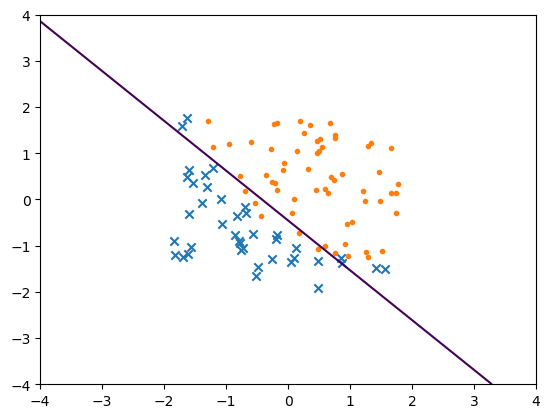

In [125]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std
w,b,best=fit(X_norm,y,10000, 0.015)
w1,w2=w
F=y==0
F_X=X_norm[F]
T_X=X_norm[~F]
fig,ax=plt.subplots()
ax.scatter(F_X[:,0],F_X[:,1],marker='x')
ax.scatter(T_X[:,0],T_X[:,1],marker='.')
i=np.linspace(-4,4,101)
xx,yy=np.meshgrid(i,i)
zz=w1*xx+w2*yy+b
ax.contour(xx,yy,zz,levels=[0])
w